In [5]:
import pandas as pd

raw_url = "https://raw.githubusercontent.com/NepalStockData/Nepal_Stock_Data/main/Nepse_Data/Commercial_Banks/NABIL.csv"

# Load into DataFrame
df = pd.read_csv(raw_url)

In [6]:
df.head()

,S.N.,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,1,2026-09-03,540.00,540.00,537.50,539.00,0.28,"21,616.00","11,650,487.20"
1,2,2026-09-02,540.00,541.90,537.00,537.50,0.19,"24,088.00","12,977,068.90"
2,3,2026-09-01,535.00,539.80,533.00,536.50,0.24,"25,051.00","13,466,224.70"
3,4,2026-08-31,540.00,545.00,535.10,535.20,-0.93,"43,318.00","23,232,512.60"
4,5,2026-08-27,535.00,542.00,530.00,540.20,0.63,"36,950.00","19,878,240.40"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.N.      3525 non-null   int64  
 1   Date      3525 non-null   object 
 2   Open      3525 non-null   object 
 3   High      3525 non-null   object 
 4   Low       3525 non-null   object 
 5   Ltp       3525 non-null   object 
 6   % Change  3525 non-null   float64
 7   Qty       3525 non-null   object 
 8   Turnover  3525 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 248.0+ KB


In [8]:
df = df.drop(df.columns[0:1], axis=1)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.head()

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2026-09-03,540.00,540.00,537.50,539.00,0.28,"21,616.00","11,650,487.20"
1,2026-09-02,540.00,541.90,537.00,537.50,0.19,"24,088.00","12,977,068.90"
2,2026-09-01,535.00,539.80,533.00,536.50,0.24,"25,051.00","13,466,224.70"
3,2026-08-31,540.00,545.00,535.10,535.20,-0.93,"43,318.00","23,232,512.60"
4,2026-08-27,535.00,542.00,530.00,540.20,0.63,"36,950.00","19,878,240.40"


In [11]:
df = df.sort_values("Date")

In [12]:
df.head()

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
3524,2011-03-20,"1,200.00","1,190.00","1,160.00","1,170.00",0.0,853.00,"1,000,811.00"
3523,2011-03-24,"1,162.00","1,178.00","1,150.00","1,153.00",0.0,356.00,"412,649.00"
3522,2011-03-25,"1,153.00","1,174.00","1,145.00","1,174.00",0.0,702.00,"807,507.00"
3521,2011-03-27,"1,174.00","1,160.00","1,120.00","1,147.00",0.0,"1,426.00","1,619,270.00"
3520,2011-03-28,"1,147.00","1,150.00","1,110.00","1,132.00",0.0,352.00,"393,534.00"


In [13]:
df = df.reset_index(drop=True)

In [14]:
df.head()

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
0,2011-03-20,"1,200.00","1,190.00","1,160.00","1,170.00",0.0,853.00,"1,000,811.00"
1,2011-03-24,"1,162.00","1,178.00","1,150.00","1,153.00",0.0,356.00,"412,649.00"
2,2011-03-25,"1,153.00","1,174.00","1,145.00","1,174.00",0.0,702.00,"807,507.00"
3,2011-03-27,"1,174.00","1,160.00","1,120.00","1,147.00",0.0,"1,426.00","1,619,270.00"
4,2011-03-28,"1,147.00","1,150.00","1,110.00","1,132.00",0.0,352.00,"393,534.00"


In [15]:
df['Turnover'] = df['Turnover'].astype(str).str.replace(',','').astype(float)

In [16]:
df.dtypes

Date        datetime64[ns]
Open                object
High                object
Low                 object
Ltp                 object
% Change           float64
Qty                 object
Turnover           float64
dtype: object

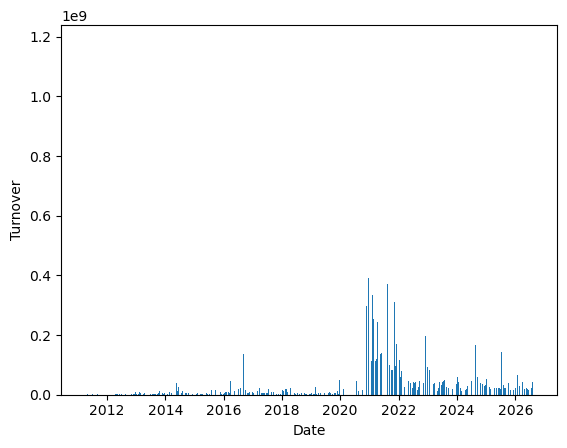

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.bar(df['Date'], df['Turnover'])
plt.xlabel('Date')
plt.ylabel('Turnover')
plt.show()

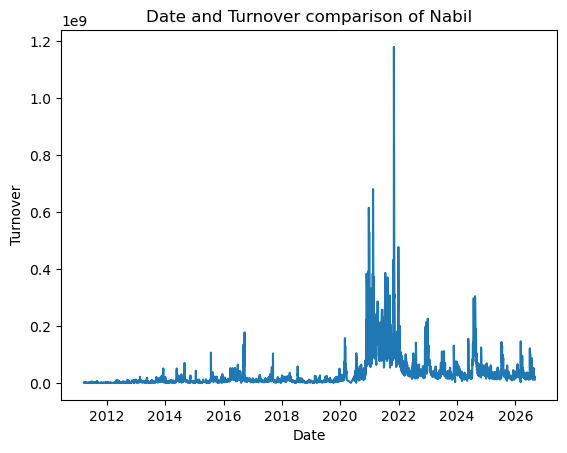

In [18]:
plt.plot(df['Date'], df['Turnover'])
plt.xlabel('Date')
plt.ylabel('Turnover')
plt.title('Date and Turnover comparison of Nabil')
plt.show()

In [19]:
print(df.dtypes)

Date        datetime64[ns]
Open                object
High                object
Low                 object
Ltp                 object
% Change           float64
Qty                 object
Turnover           float64
dtype: object


In [20]:
df.loc[df['Turnover'].idxmax()]

Date        2021-11-03 00:00:00
Open                   1,640.10
High                   1,740.00
Low                    1,640.10
Ltp                    1,653.00
% Change                    2.8
Qty                  705,430.00
Turnover           1179786179.7
Name: 2402, dtype: object

In [21]:
print(df.nlargest(10, 'Turnover')[['Date', 'Turnover']])

           Date      Turnover
2402 2021-11-03  1.179786e+09
2230 2021-02-15  6.805165e+08
2194 2020-12-24  6.149659e+08
2231 2021-02-16  5.444560e+08
2197 2020-12-29  5.301780e+08
2438 2021-12-29  4.771821e+08
2397 2021-10-27  4.319315e+08
2232 2021-02-17  4.116253e+08
2195 2020-12-27  4.049214e+08
2190 2020-12-20  3.923211e+08


In [22]:
df.isnull().sum()

Date        0
Open        0
High        0
Low         0
Ltp         0
% Change    0
Qty         0
Turnover    0
dtype: int64

In [23]:
df[df.isnull().any(axis=1)]

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover


In [24]:
df.duplicated().sum()

np.int64(1)

Check if duplicated value appeared

In [25]:
df[df['Date'].duplicated(keep=False)]

,Date,Open,High,Low,Ltp,% Change,Qty,Turnover
344,2012-10-01,"1,400.00","1,428.00","1,400.00","1,402.00",0.0,"4,518.00",6343649.0
345,2012-10-01,"1,400.00","1,428.00","1,400.00","1,402.00",0.0,"4,518.00",6343649.0


In [26]:
df.dtypes

Date        datetime64[ns]
Open                object
High                object
Low                 object
Ltp                 object
% Change           float64
Qty                 object
Turnover           float64
dtype: object

In [27]:
cols = ['Open', 'High', 'Low', 'Ltp', 'Qty']

for col in cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''),
    )

In [28]:
df.loc[df['Ltp'].idxmax(), ['Date', 'Ltp']]

Date    2013-12-08 00:00:00
Ltp                  2750.0
Name: 612, dtype: object

In [29]:
df.loc[df['Ltp'].idxmin(), ['Date', 'Ltp']]

Date    2024-05-07 00:00:00
Ltp                   422.0
Name: 2990, dtype: object

In [30]:
df['Ltp'].min()

422.0

In [31]:
df['Ltp'].mean()

np.float64(1195.700059574468)

In [32]:
df['Ltp'].std()

594.791595540076

In [33]:
df.loc[df['High'].idxmax()]

Date        2013-12-05 00:00:00
Open                     2715.0
High                     2800.0
Low                      2695.0
Ltp                      2720.0
% Change                    0.0
Qty                      9860.0
Turnover             27147946.0
Name: 611, dtype: object

In [34]:
#Biggest one day increase
df.nlargest(10, '% Change')[
    ['Date', 'Ltp', '% Change']
    ]

,Date,Ltp,% Change
2088,2020-07-19,869.0,10.00
2192,2020-12-22,1354.0,9.99
3045,2024-07-28,633.4,9.98
2193,2020-12-23,1489.0,9.97
2075,2020-06-30,725.0,9.85
2057,2020-02-27,955.0,9.77
2174,2020-11-26,1130.0,8.86
2230,2021-02-15,1321.0,8.19
3402,2026-03-09,545.0,8.13
2951,2024-03-04,458.3,8.09


In [35]:
df.nsmallest(10, '% Change')[
    ['Date', 'Ltp', '% Change']
    ]

,Date,Ltp,% Change
2010,2019-12-24,667.0,-11.07
2059,2020-03-02,850.0,-9.57
2884,2023-11-23,515.0,-8.20
2063,2020-03-10,776.0,-7.62
2077,2020-07-02,720.0,-6.49
3305,2025-09-18,483.0,-5.88
2180,2020-12-06,1078.0,-5.44
3051,2024-08-06,625.0,-5.30
1582,2018-03-26,925.0,-5.13
2066,2020-03-15,750.0,-5.06


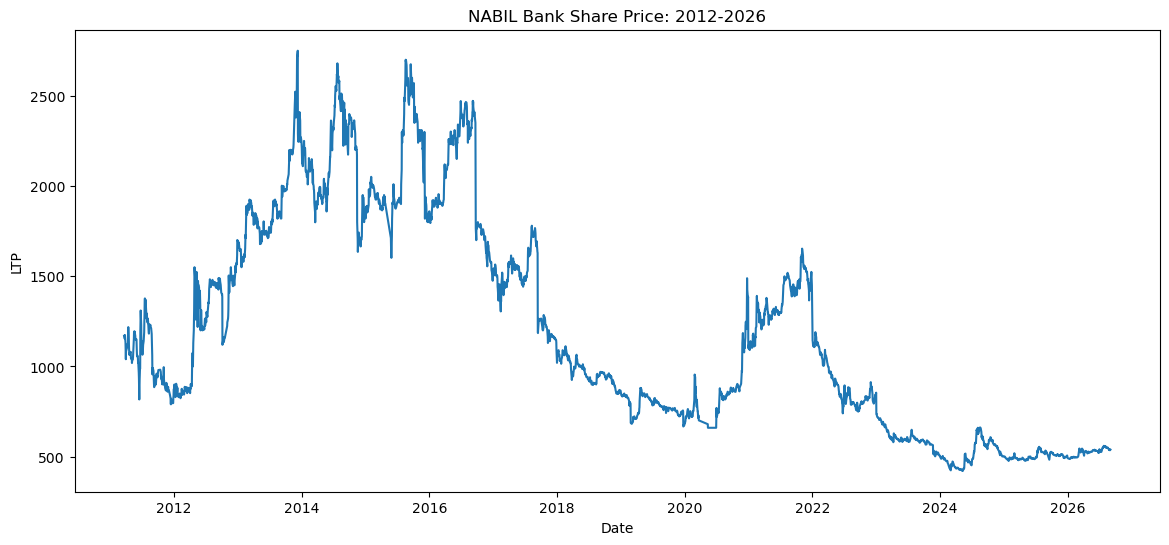

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Ltp'])

plt.title('NABIL Bank Share Price: 2012-2026')
plt.xlabel('Date')
plt.ylabel('LTP')
plt.show()

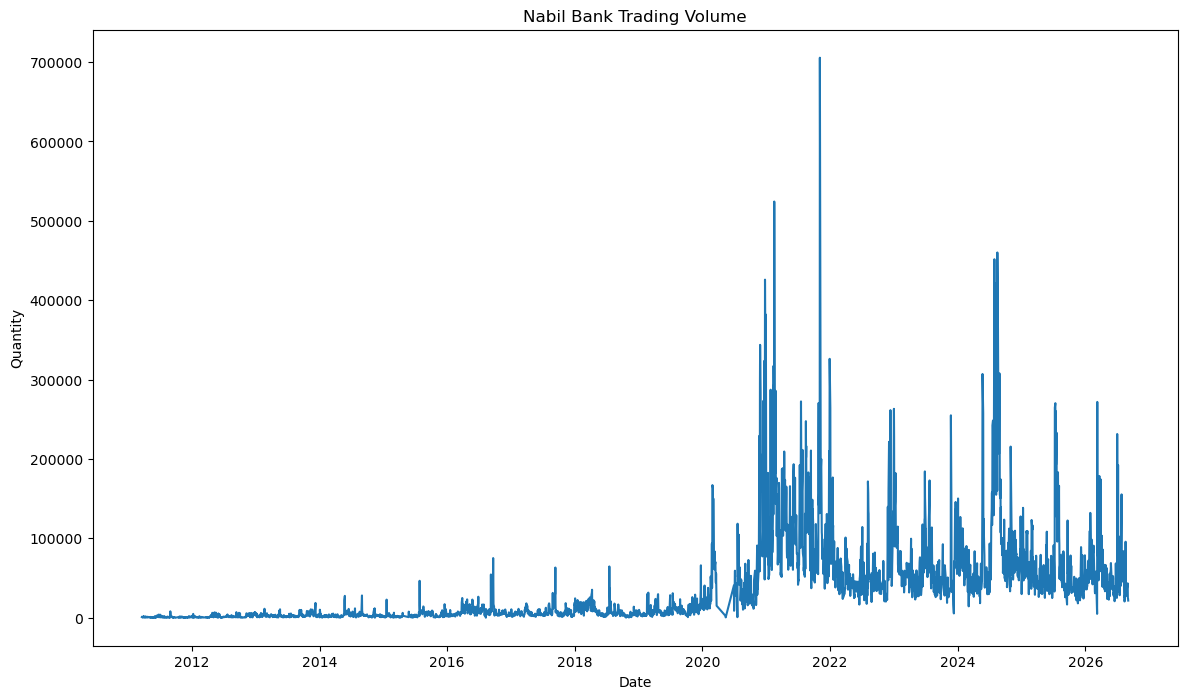

In [37]:
plt.figure(figsize=(14,8))
plt.plot(df['Date'], df['Qty'])

plt.title('Nabil Bank Trading Volume')
plt.xlabel('Date')
plt.ylabel('Quantity')

plt.show()

In [38]:
df.loc[df['Turnover'].idxmax(), ['Date', 'Ltp','Turnover']]

Date        2021-11-03 00:00:00
Ltp                      1653.0
Turnover           1179786179.7
Name: 2402, dtype: object

In [39]:
df.nlargest(5, 'Turnover')[['Date', 'Ltp', 'Turnover']]

,Date,Ltp,Turnover
2402,2021-11-03,1653.0,1.179786e+09
2230,2021-02-15,1321.0,6.805165e+08
2194,2020-12-24,1425.0,6.149659e+08
2231,2021-02-16,1365.0,5.444560e+08
2197,2020-12-29,1386.0,5.301780e+08


In [40]:
df['Daily_Return'] = df['Ltp'].pct_change()

In [41]:
df['Daily_Return_Pct'] = df['Daily_Return'] * 100

In [42]:
df['Daily_Return_Pct'].describe()

count    3524.000000
mean        0.002978
std         2.203122
min       -26.932515
25%        -0.742543
50%        -0.058890
75%         0.630044
max        20.871327
Name: Daily_Return_Pct, dtype: float64

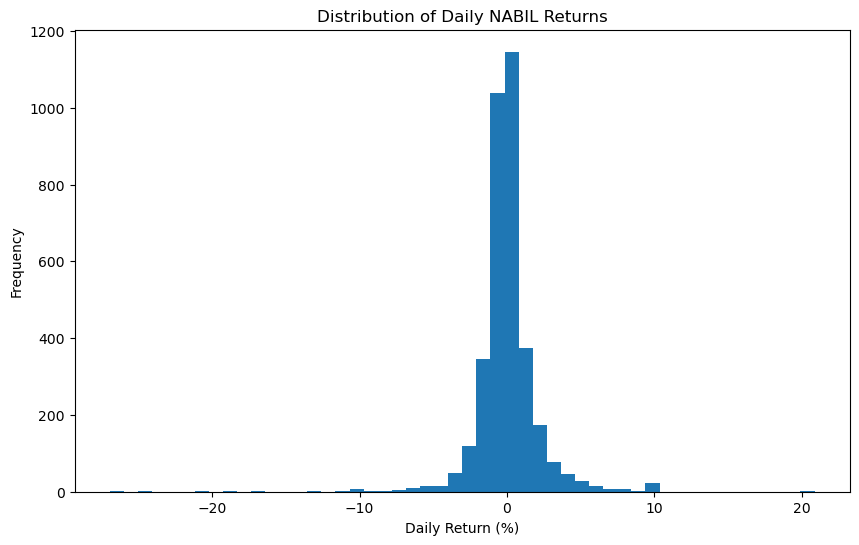

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['Daily_Return_Pct'].dropna(),
    bins=50
)

plt.title('Distribution of Daily NABIL Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')

plt.show()

In [44]:
df['Year'] = df['Date'].dt.year

In [45]:
yearly = df.groupby('Year').agg(
    Average_Price=('Ltp', 'mean'),
    Highest_Price=('High', 'max'),
    Lowest_Price=('Low', 'min'),
    Average_Volume=('Qty', 'mean'),
    Total_Turnover=('Turnover', 'sum')
)

yearly

,Average_Price,Highest_Price,Lowest_Price,Average_Volume,Total_Turnover
Year,,,,,
2011,1038.686391,1410.0,781.0,880.236686,1.543755e+08
2012,1234.938596,1701.0,814.0,1690.403509,5.222611e+08
2013,1899.513043,2800.0,1540.0,3027.082609,1.376834e+09
2014,2138.502203,2680.0,1564.0,3377.621145,1.655871e+09
2015,2095.562791,2794.0,1575.0,3612.162791,1.705648e+09
2016,2045.556034,2548.0,1421.0,8073.732759,4.015278e+09
2017,1438.826087,1810.0,1015.0,6550.104348,2.215188e+09
2018,965.150000,1130.0,830.0,8651.912500,2.033916e+09
2019,782.918367,900.0,660.0,9776.983673,1.855379e+09


In [46]:
annual_price = (
    df.set_index('Date')['Ltp']
    .resample('YE')
    .last()
)

In [47]:
annual_return = annual_price.pct_change()*100

In [48]:
print(annual_return)

Date
2011-12-31          NaN
2012-12-31    93.928981
2013-12-31    30.537507
2014-12-31   -17.647059
2015-12-31     2.197802
2016-12-31   -18.333333
2017-12-31   -32.850560
2018-12-31   -15.686275
2019-12-31   -20.813953
2020-12-31    61.527166
2021-12-31    31.818182
2022-12-31   -41.862069
2023-12-31   -39.976275
2024-12-31    -0.790514
2025-12-31    -1.055777
2026-12-31     8.516207
Freq: YE-DEC, Name: Ltp, dtype: float64


In [49]:
#nabil best performing year
annual_return.idxmax(), annual_return.max()

(Timestamp('2012-12-31 00:00:00'), 93.92898052691866)

In [50]:
annual_return.idxmin(), annual_return.min()

(Timestamp('2022-12-31 00:00:00'), -41.86206896551724)

In [51]:
#annual return avergae
avg_return = annual_return.mean()

In [52]:
print(avg_return)

2.634002012762205


In [53]:
monthly_price = (
    df.set_index('Date')['Ltp']
    .resample('ME')
    .last()
)

In [54]:
monthly_return = monthly_price.pct_change() * 100

C:\Users\ashim\AppData\Local\Temp\ipykernel_38128\3463522630.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_return = monthly_price.pct_change() * 100


In [55]:
monthly_df = monthly_return.to_frame('Return')
monthly_df['Month'] = monthly_df.index.month

In [56]:
monthly_df.groupby('Month')['Return'].mean()

Month
1     -3.456221
2      2.163409
3     -2.504999
4      4.982385
5     -1.213017
6      1.953832
7     10.812664
8     -3.130552
9     -3.702721
10    -0.231246
11    -1.165342
12    -3.397592
Name: Return, dtype: float64

In [57]:
#finding the moving average
df['MA_20'] = df['Ltp'].rolling(20).mean()
df['MA_50'] = df['Ltp'].rolling(50).mean()
df['MA_200'] = df['Ltp'].rolling(200).mean()

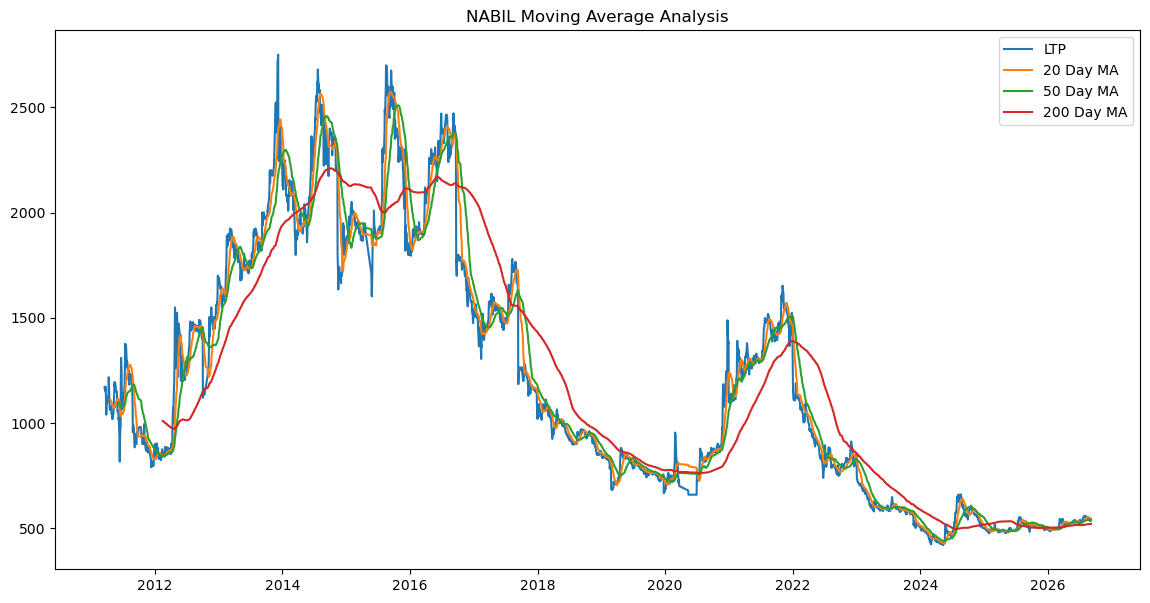

In [58]:
plt.figure(figsize=(14, 7))

plt.plot(df['Date'], df['Ltp'], label='LTP')
plt.plot(df['Date'], df['MA_20'], label='20 Day MA')
plt.plot(df['Date'], df['MA_50'], label='50 Day MA')
plt.plot(df['Date'], df['MA_200'], label='200 Day MA')

plt.legend()
plt.title('NABIL Moving Average Analysis')

plt.show()

In [59]:
#volatility analysis
df['Volatility_30'] = (
    df['Daily_Return']
    .rolling(30)
    .std()
)

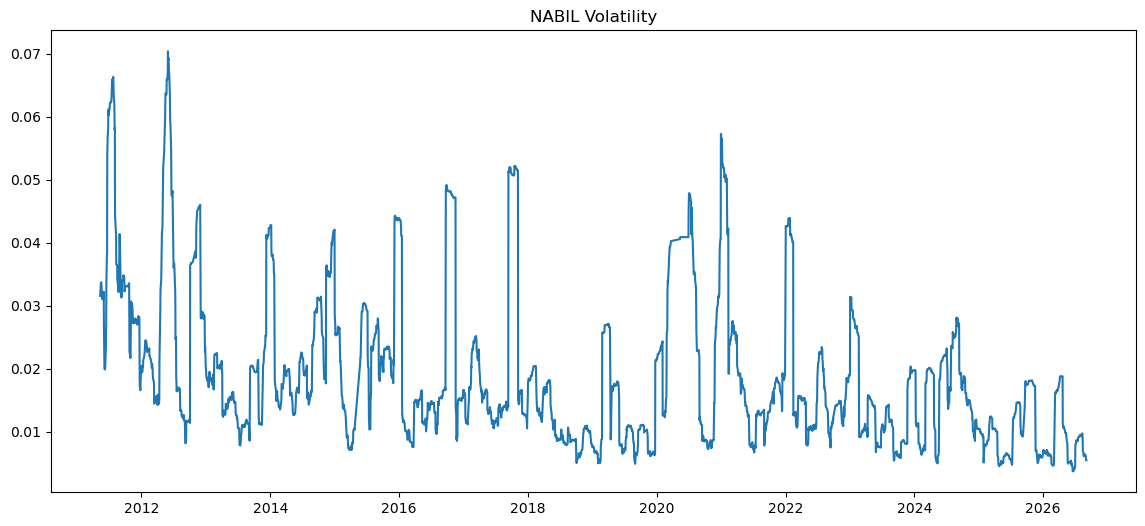

In [60]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Volatility_30'])
plt.title('NABIL Volatility')
plt.show()

In [61]:
tdpy = (
    df.groupby(df['Date'].dt.year)
    .size()
    .median()
)

tdpy

229.0

In [62]:
annual_volatility = (
    df['Daily_Return'].std()
    * tdpy ** 0.5
)

In [63]:
df['Running_Max'] = df['Ltp'].cummax()

In [64]:
df['Drawdown'] = (
    df['Ltp'] / df['Running_Max'] - 1
)

In [65]:
df['Drawdown_Pct'] = df['Drawdown'] * 100

In [66]:
df['Drawdown_Pct'].min()

-84.65454545454546

In [67]:
df['Drawdown_Pct'].idxmin()

2990

In [68]:
#Last Liquidity analysis
yearly_liquidity = df.groupby('Year').agg(
    Avg_Qty=('Qty', 'mean'),
    Avg_Turnover=('Turnover','mean')
)
yearly_liquidity

,Avg_Qty,Avg_Turnover
Year,,
2011,880.236686,9.134648e+05
2012,1690.403509,2.290619e+06
2013,3027.082609,5.986236e+06
2014,3377.621145,7.294586e+06
2015,3612.162791,7.933247e+06
2016,8073.732759,1.730723e+07
2017,6550.104348,9.631252e+06
2018,8651.912500,8.474649e+06
2019,9776.983673,7.572975e+06


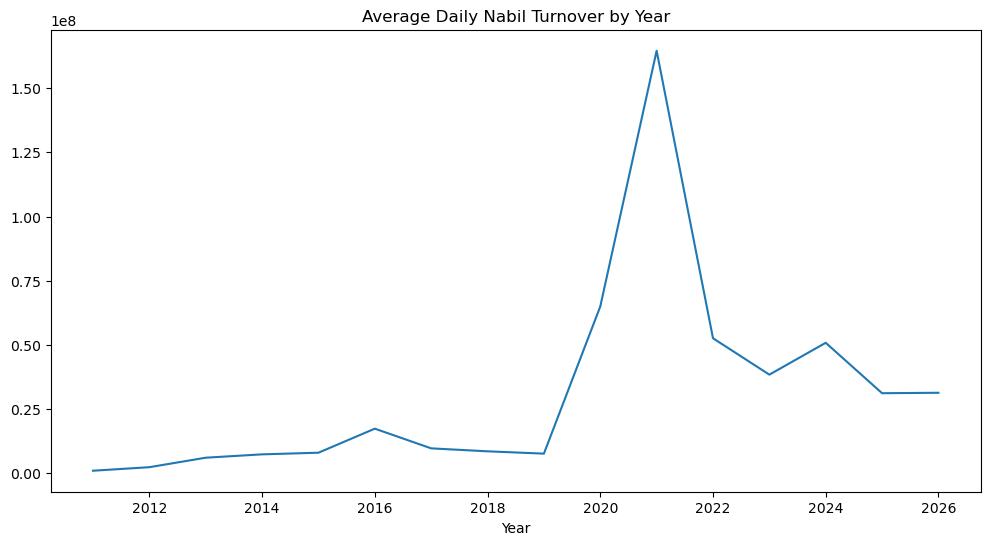

In [69]:
#plotting turnover
yearly_liquidity['Avg_Turnover'].plot(
    figsize=(12,6)
)
plt.title('Average Daily Nabil Turnover by Year')
plt.show()

In [70]:
df = df.sort_values("Date")

df["cum_max"] = df["Ltp"].cummax()

df["drawdown"] = (
    df["Ltp"] / df["cum_max"] -1 
) * 100

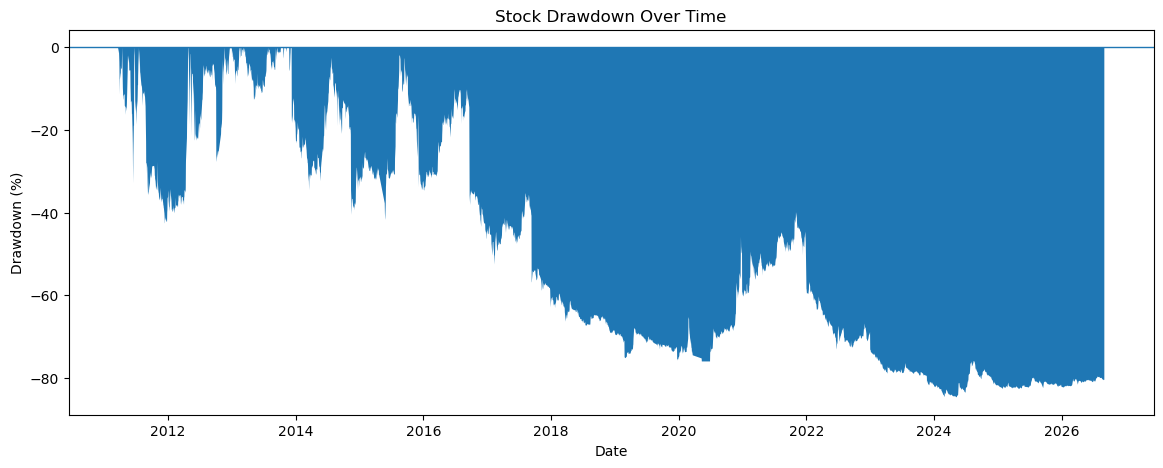

In [72]:
plt.figure(figsize=(14,5))

plt.fill_between(
    df["Date"],
    df["drawdown"],
    0
)

plt.axhline(0, linewidth=1)

plt.title("Stock Drawdown Over Time")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")

plt.show()

Rolling  Maximum Drawdown

In [73]:
window = 252

rolling_max = df["Ltp"].rolling(window).max()

df["rolling_drawdown"] = (
    df["Ltp"] / rolling_max - 1
) * 100

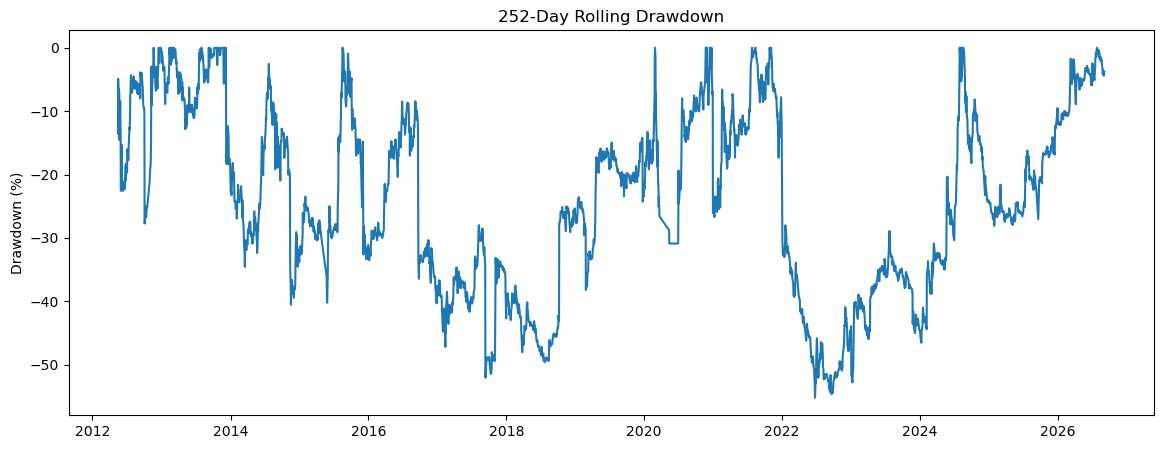

In [74]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["rolling_drawdown"])

plt.title("252-Day Rolling Drawdown")
plt.ylabel("Drawdown (%)")
plt.show()

Return Distribution

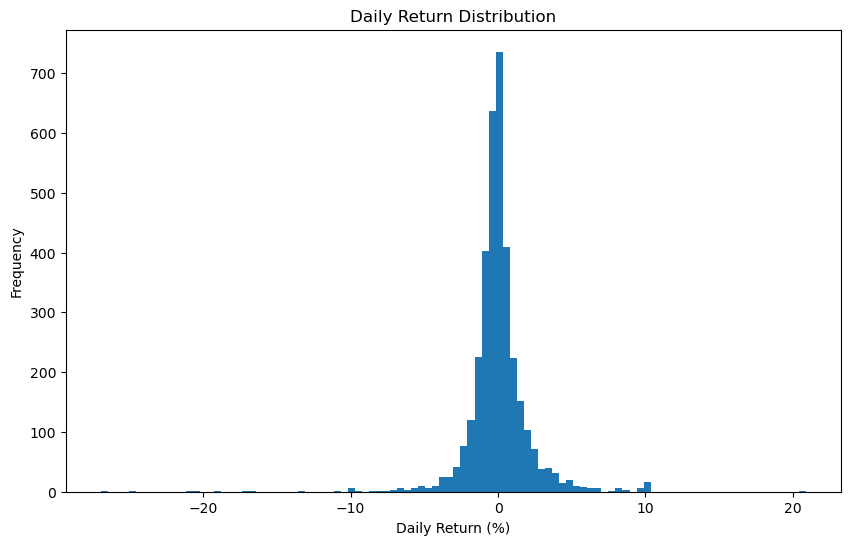

In [76]:
returns = df["Ltp"].pct_change().dropna() * 100

plt.figure(figsize=(10,6))
plt.hist(returns, bins=100)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")

plt.show()

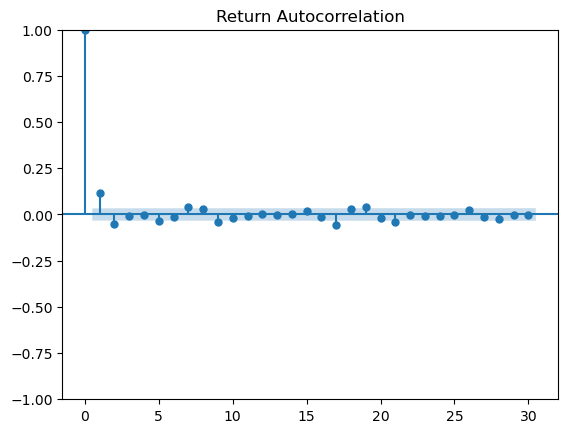

In [83]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    df["Daily_Return"].dropna(),
    lags=30
)

plt.title("Return Autocorrelation")
plt.show()

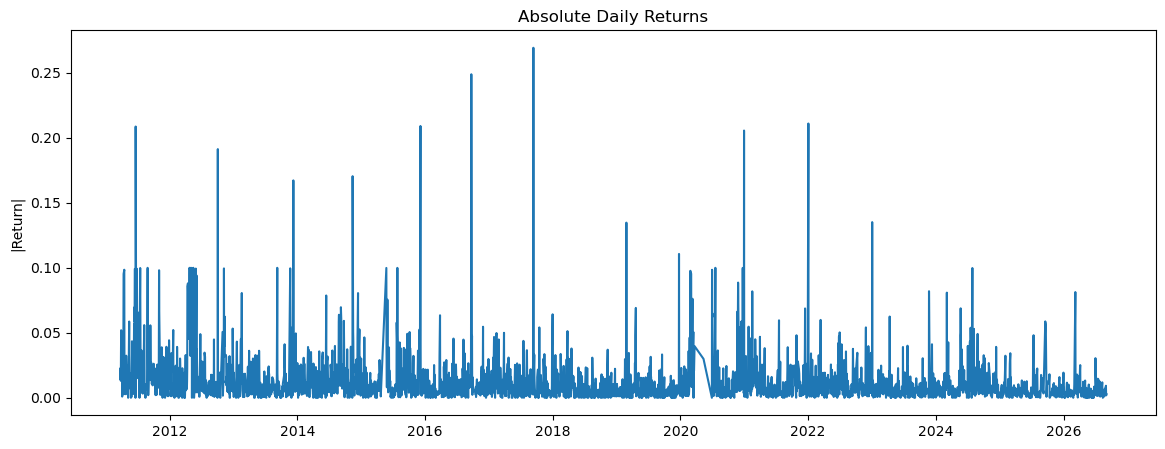

In [84]:
plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Daily_Return"].abs()
)

plt.title("Absolute Daily Returns")
plt.ylabel("|Return|")

plt.show()

In [86]:
! pip install arch

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 929.7/929.7 kB 9.4 MB/s  0:00:00


In [89]:
from arch import arch_model

r = df["Daily_Return"].dropna() * 100

model = arch_model(
    r,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1
)

result = model.fit()

print(result.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 22828.048072733865
Iteration:      2,   Func. Count:     15,   Neg. LLF: 19295.892427702893
Iteration:      3,   Func. Count:     23,   Neg. LLF: 7862.581474310061
Iteration:      4,   Func. Count:     29,   Neg. LLF: 7327.917905251262
Iteration:      5,   Func. Count:     34,   Neg. LLF: 7444.398601992934
Iteration:      6,   Func. Count:     41,   Neg. LLF: 7327.191151228528
Iteration:      7,   Func. Count:     47,   Neg. LLF: 7325.81969850171
Iteration:      8,   Func. Count:     52,   Neg. LLF: 7325.819601085543
Iteration:      9,   Func. Count:     57,   Neg. LLF: 7325.819599669711
Iteration:     10,   Func. Count:     61,   Neg. LLF: 7325.819598778669
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7325.819599669711
            Iterations: 10
            Function evaluations: 61
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results              

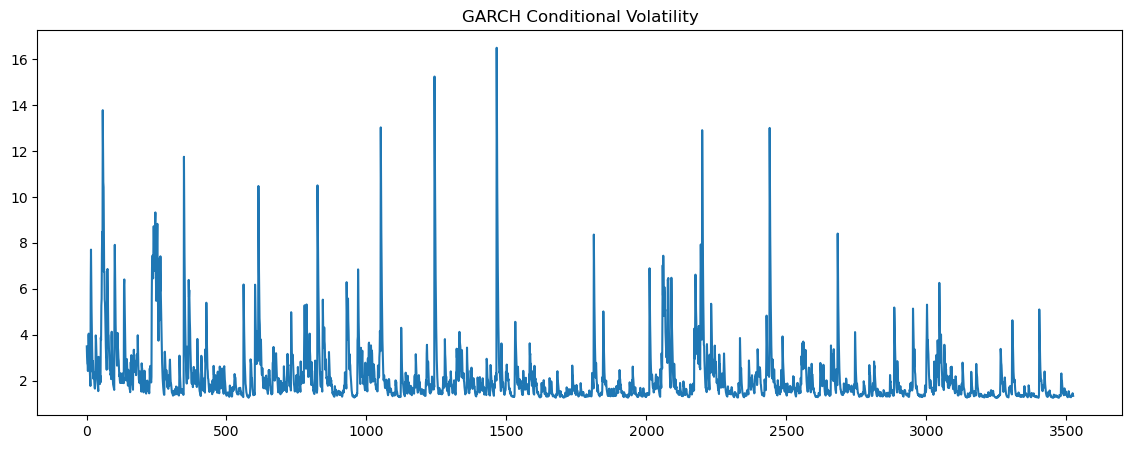

In [90]:
conditional_vol = result.conditional_volatility

plt.figure(figsize=(14,5))

plt.plot(
    conditional_vol.index,
    conditional_vol
)

plt.title("GARCH Conditional Volatility")

plt.show()